# VoxBind - Docking Metric Plots

Loads the cached `metrics.json` files - the same data source as
`00_dashboard.ipynb` - and plots the docking (AutoDock Vina) metrics.

### How to use
1. Run **section 0 (Setup)** once. It reuses the dashboard's loader and
   discovers every experiment / run under
   `voxbind/exps/<experiment>/samples/<run>/target_*/`.
2. **Section 1** prints one row per `(experiment, run)`; note the `idx` of
   the runs you want to plot.
3. In **section 2**, set `SELECTED_RUNS` to those `idx` values (or leave it
   `None` for all runs) and run the cell to draw the box plots.

### Notes
- Like the dashboard, this notebook only *reads* pre-computed `metrics.json`;
  refresh those files with the Streamlit app (`notebook/webapp/app.py`).
- Vina energies are in kcal/mol and **lower is better** for every variant
  (`score_only`, `minimize`, `dock`).
- Each bar's tip is the **Avg** Vina energy over a run's pooled samples;
  the red tick on the bar is the **Med**; per-target reference-ligand bars
  are no longer drawn (the paper baselines provide the comparison rows).
- Runs with no docking metrics computed are skipped and flagged in section 2.

In [1]:
# Section 0 - Setup: helper functions (run once).
import json
import math
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 260)
pd.set_option("display.max_colwidth", 100)


def show(obj, round_to=3):
    """Render a DataFrame/Series in Jupyter, falling back to plain text."""
    if isinstance(obj, (pd.DataFrame, pd.Series)):
        obj = obj.round(round_to)
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)


# -- locate the repository ---------------------------------------------------
def find_repo_root() -> Path:
    """Walk up from the working directory until voxbind/exps/ is found."""
    for cand in [Path.cwd(), *Path.cwd().parents]:
        if (cand / "voxbind" / "exps").is_dir():
            return cand
    fallback = Path("/home/shpark/prj-denovo/VoxBind")
    if (fallback / "voxbind" / "exps").is_dir():
        return fallback
    raise FileNotFoundError("Could not find voxbind/exps/ - run from inside the repo.")


REPO = find_repo_root()
EXPS_ROOT = REPO / "voxbind" / "exps"
METRICS_VERSION = 2          # version stamp written by notebook/webapp/metrics.py
print(f"repo      : {REPO}")
print(f"exps root : {EXPS_ROOT}")


# -- experiment / run / target discovery -------------------------------------
def list_runs(exp_dir: Path) -> list:
    """Sampling-run subdirs under <exp>/samples/ that hold target_* folders."""
    samples = exp_dir / "samples"
    if not samples.is_dir():
        return []
    return sorted(d.name for d in samples.iterdir()
                  if d.is_dir() and any(d.glob("target_*")))


def list_experiments() -> list:
    """Experiment names with at least one non-empty sampling run."""
    if not EXPS_ROOT.is_dir():
        return []
    return sorted(p.name for p in EXPS_ROOT.iterdir()
                  if p.is_dir() and list_runs(p))


def list_targets(exp_name: str, run: str) -> list:
    """Sorted target_* directories for one (experiment, run)."""
    run_dir = EXPS_ROOT / exp_name / "samples" / run
    if not run_dir.is_dir():
        return []
    return sorted(t for t in run_dir.glob("target_*") if t.is_dir())


# -- metrics.json loading and freshness --------------------------------------
def metrics_status(target_dir: Path) -> str:
    """One of: fresh | stale | no-metrics | no-samples."""
    mp = target_dir / "metrics.json"
    sdf = target_dir / "samples.sdf"
    if not sdf.exists():
        return "no-samples"
    if not mp.exists():
        return "no-metrics"
    try:
        data = json.loads(mp.read_text())
    except (json.JSONDecodeError, OSError):
        return "no-metrics"
    if data.get("version") != METRICS_VERSION:
        return "stale"
    return "fresh" if mp.stat().st_mtime >= sdf.stat().st_mtime else "stale"


def load_metrics(target_dir: Path):
    """Parsed metrics.json dict, or None if absent / unreadable."""
    mp = target_dir / "metrics.json"
    if not mp.exists():
        return None
    try:
        return json.loads(mp.read_text())
    except (json.JSONDecodeError, OSError):
        return None


# -- docking metrics (Vina) - optional, may not be computed yet --------------
# Per-sample docking is expected either as a nested {"vina": {...}} dict
# (poc_evaluate.py convention) or as flat vina_* keys. When nothing is found,
# the vina_* columns stay NaN and the dashboard flags the target/experiment.
VINA_COLS = ["vina_score", "vina_min", "vina_dock"]
_VINA_NESTED = {"score_only": "vina_score", "minimize": "vina_min", "dock": "vina_dock"}


def sample_docking(sample: dict) -> dict:
    """Extract {vina_score, vina_min, vina_dock} from one sample record."""
    out = {}
    v = sample.get("vina")
    if isinstance(v, dict) and "error" not in v:
        for src, dst in _VINA_NESTED.items():
            if isinstance(v.get(src), (int, float)):
                out[dst] = float(v[src])
    for col in VINA_COLS:
        if isinstance(sample.get(col), (int, float)):
            out[col] = float(sample[col])
    return out


def target_docking(metrics: dict) -> dict:
    """Mean Vina metrics for a target - NaN for any not computed."""
    out = {c: float("nan") for c in VINA_COLS}
    acc = {c: [] for c in VINA_COLS}
    for s in metrics.get("samples", []):
        for c, val in sample_docking(s).items():
            acc[c].append(val)
    for c in VINA_COLS:
        if acc[c]:
            out[c] = float(np.mean(acc[c]))
    # fall back to aggregate-level keys, in case a future pipeline writes them there
    agg = metrics.get("aggregates", {})
    aliases = {
        "vina_score": ("vina_score_mean", "vina_score", "Vina score mean"),
        "vina_min":   ("vina_min_mean", "vina_min", "Vina min mean"),
        "vina_dock":  ("vina_dock_mean", "vina_dock", "Vina dock mean"),
    }
    for c, names in aliases.items():
        if math.isnan(out[c]):
            for n in names:
                if isinstance(agg.get(n), (int, float)):
                    out[c] = float(agg[n])
                    break
    return out


def has_docking(metrics) -> bool:
    """True if any Vina metric is present in this target's metrics."""
    return metrics is not None and any(
        not math.isnan(v) for v in target_docking(metrics).values()
    )


print("setup ready: list_experiments, list_runs, list_targets, load_metrics,")
print("             metrics_status, has_docking, sample_docking")


# -- paper baselines (figures/voxbind_results.png) ---------------------------
# Hand-transcribed (avg, med) per Vina variant for the published baselines on
# CrossDocked2020. None means the paper printed a dash (no value reported).
# Same numbers live in 00_dashboard.ipynb's PAPER_BASELINES — keep them in sync.
PAPER_BASELINES = {
    "Reference":     {"vina_score": (-6.36, -6.46), "vina_min": (-6.71, -6.49),
                      "vina_dock":  (-7.45, -7.26), "high_affinity": (None, None),
                      "qed": (0.48, 0.47),          "sa":  (0.73, 0.74),
                      "diversity": (None, None),    "atoms": (22.8, 21.5)},
    "AR":            {"vina_score": (-5.75, -5.64), "vina_min": (-6.18, -5.88),
                      "vina_dock":  (-6.75, -6.62), "high_affinity": (37.9, 31.0),
                      "qed": (0.51, 0.50),          "sa":  (0.63, 0.63),
                      "diversity": (0.70, 0.70),    "atoms": (17.6, 16.0)},
    "Pocket2Mol":    {"vina_score": (-5.14, -4.70), "vina_min": (-6.42, -5.82),
                      "vina_dock":  (-7.15, -6.79), "high_affinity": (48.4, 51.0),
                      "qed": (0.56, 0.57),          "sa":  (0.74, 0.75),
                      "diversity": (0.69, 0.71),    "atoms": (17.7, 15.0)},
    "DiffSBDD":   {"vina_score": (-1.94, -4.24), "vina_min": (-5.85, -5.94),
                      "vina_dock":  (-7.00, -6.90), "high_affinity": (46.3, 47.2),
                      "qed": (0.48, 0.48),          "sa":  (0.58, 0.57),
                      "diversity": (0.73, 0.72),    "atoms": (24.0, 23.0)},
    "TargetDiff":    {"vina_score": (-5.47, -6.23), "vina_min": (-6.64, -6.83),
                      "vina_dock":  (-7.80, -7.91), "high_affinity": (58.1, 59.1),
                      "qed": (0.48, 0.48),          "sa":  (0.58, 0.58),
                      "diversity": (0.72, 0.71),    "atoms": (24.2, 24.0)},
    "DecompDiff":    {"vina_score": (-5.67, -6.04), "vina_min": (-7.04, -7.09),
                      "vina_dock":  (-8.39, -8.43), "high_affinity": (64.4, 71.0),
                      "qed": (0.45, 0.43),          "sa":  (0.61, 0.60),
                      "diversity": (0.68, 0.68),    "atoms": (20.9, 21.0)},
    "VoxBind 0.9": {"vina_score": (-6.94, -7.11), "vina_min": (-7.54, -7.55),
                      "vina_dock":  (-8.30, -8.41), "high_affinity": (71.3, 71.5),
                      "qed": (0.57, 0.58),          "sa":  (0.70, 0.69),
                      "diversity": (0.73, 0.74),    "atoms": (23.4, 24.0)},
    "VoxBind 1.0": {"vina_score": (-6.63, -6.70),  "vina_min": (-7.12, -7.18),
                      "vina_dock":  (-7.82, -7.89),   "high_affinity": (58.3, 61.5),
                      "qed": (0.55, 0.57),          "sa":  (0.69, 0.69),
                      "diversity": (0.75, 0.76),    "atoms": (21.7, 22.0)},
}


def experiment_run_table() -> pd.DataFrame:
    """Discover every (experiment, run) pair and summarise its coverage."""
    rows = []
    for exp_name in list_experiments():
        for run in list_runs(EXPS_ROOT / exp_name):
            targets = list_targets(exp_name, run)
            n_fresh = n_dock = n_samples = 0
            for tdir in targets:
                if metrics_status(tdir) == "fresh":
                    n_fresh += 1
                m = load_metrics(tdir)
                if has_docking(m):
                    n_dock += 1
                if m is not None:
                    n_samples += len(m.get("samples", []))
            rows.append({
                "experiment": exp_name,
                "run": run,
                "targets": len(targets),
                "evaluated": f"{n_fresh}/{len(targets)}",
                "docking": f"{n_dock}/{len(targets)}" if n_dock else "none",
                "samples": n_samples,
            })
    df = pd.DataFrame(rows)
    df.index.name = "idx"
    return df


RUN_TABLE = experiment_run_table()
if RUN_TABLE.empty:
    print(f"No experiments with generated samples under {EXPS_ROOT}")
else:
    print(f"{len(RUN_TABLE)} (experiment, run) pair(s) - idx is the plot selector:")
    show(RUN_TABLE)

repo      : /home/shpark/prj-denovo/VoxBind
exps root : /home/shpark/prj-denovo/VoxBind/voxbind/exps
setup ready: list_experiments, list_runs, list_targets, load_metrics,
             metrics_status, has_docking, sample_docking
12 (experiment, run) pair(s) - idx is the plot selector:


,experiment,run,targets,evaluated,docking,samples
idx,,,,,,
0,260518_voxbind_10k_baseline,res_ep99_test,92,92/92,92/92,917
1,260518_voxbind_10k_noise,res_ep99_test,63,62/63,62/63,618
2,260519_voxbind_10k_density_aligned,res_test_n10,8,8/8,7/8,79
3,260519_voxbind_10k_density_aligned,res_test_n10_ep138,50,50/50,50/50,499
4,260521_voxbind_10k_density_mae_frozen,res_ep199_quick10,2,2/2,2/2,20
5,260521_voxbind_10k_density_mae_frozen,res_ep99_quick10,2,2/2,2/2,20
6,260523_voxbind_10k_density_vit_mae_frozen,res_ep379_10pockets,10,10/10,10/10,100
7,260523_voxbind_10k_density_vit_mae_frozen,res_ep379_fulltest,79,79/79,79/79,788
8,260525_voxbind_10k_density_vit_electra_frozen,res_electra_fulltest,78,40/78,29/78,399


## Docking metric bar charts

Per-run Vina averages for the selected runs - one stacked panel per variant
(`score_only`, `minimize`, `dock`). Each `(experiment, run)` is one **hanging
bar** whose tip lands at the Avg over its pooled samples; a red horizontal
tick on each bar marks the Med, and `Avg (Med)` is printed underneath. Lower
Vina energy is better.

Layout:
1. **Paper baselines** from `figures/voxbind_results.png` on the left
   (light-grey bars, bold labels).
2. Vertical dashed black divider.
3. The colored bars for each `(experiment, run)` in `SELECTED_RUNS`,
   visually grouped by sampling-type with a faint dotted divider between
   groups.

Set `SELECTED_RUNS` to a list of `idx` values from the table above (or
`(experiment, run)` tuples); leave it `None` to plot every run.

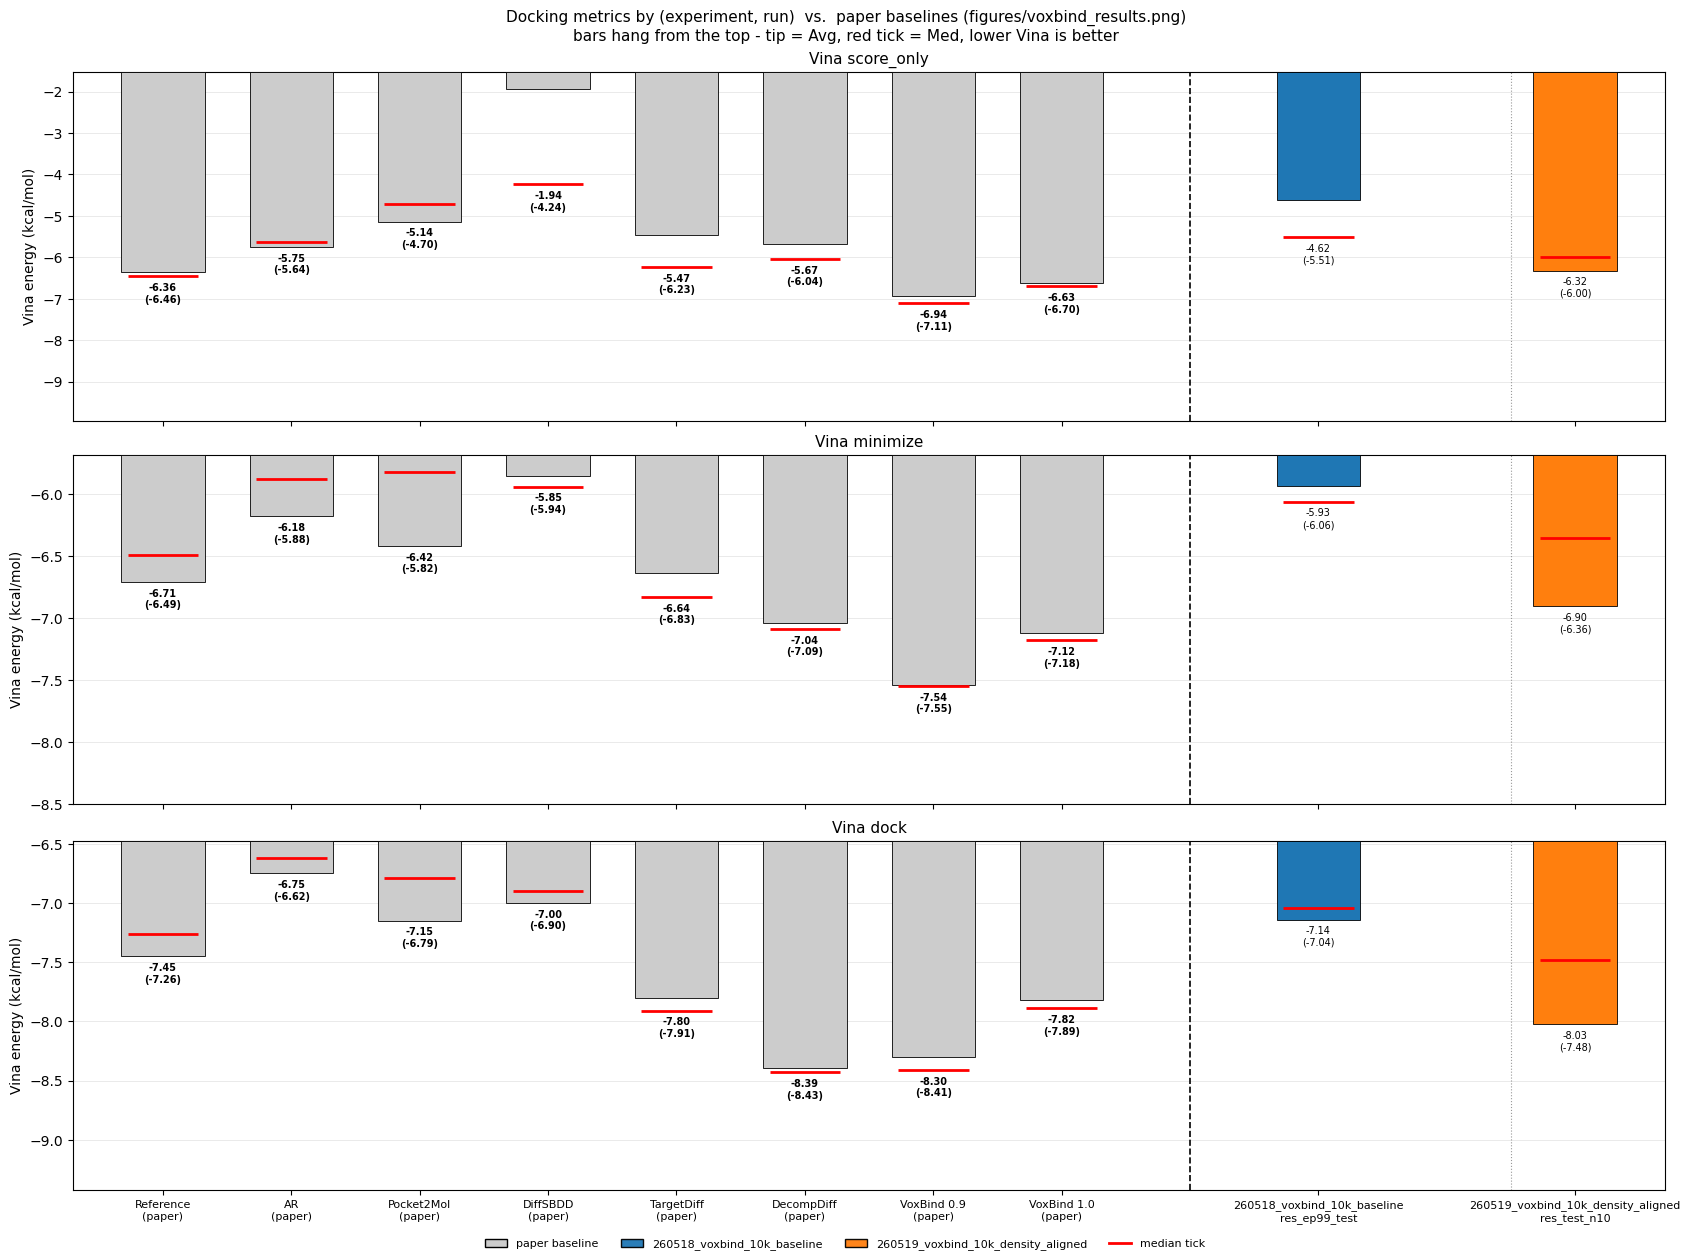

mean Vina energy (kcal/mol) - generated samples:


,,score_only,minimize,dock,n
experiment,run,,,,
260518_voxbind_10k_baseline,res_ep99_test,-4.616,-5.932,-7.139,917
260519_voxbind_10k_density_aligned,res_test_n10,-6.319,-6.902,-8.026,70


In [3]:
# Section 1 - docking (Vina) hanging-bar charts for the selected runs.
# Bars hang from the top of each panel - the bar tip lands at the Avg value,
# the bar base is anchored to the top of the y-range. A red horizontal tick
# marks the Med, and "Avg (Med)" is printed below each bar. Paper baselines
# get the same treatment as our runs so all values line up visually.
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ======================================================================
#  vvv  SELECT RUNS TO PLOT  vvv
#  idx values from the table above, (experiment, run) tuples, or None for all.
SELECTED_RUNS = [0, 2]
# SELECTED_RUNS = [7, 8, 11]
# ======================================================================

VINA_PANELS = [
    ("vina_score", "score_only"),
    ("vina_min",   "minimize"),
    ("vina_dock",  "dock"),
]


def run_vina_distributions(exp_name: str, run: str) -> dict:
    """Pooled Vina values for one run.

    Returns {"gen": {col: [values]}} where col is one of VINA_COLS - the
    per-target reference-ligand baseline is intentionally not collected; the
    paper baselines provide all the comparison rows we plot.
    """
    gen = {c: [] for c in VINA_COLS}
    for tdir in list_targets(exp_name, run):
        m = load_metrics(tdir)
        if m is None:
            continue
        for s in m.get("samples", []):
            for c, val in sample_docking(s).items():
                gen[c].append(val)
    return {"gen": gen}


# -- resolve SELECTED_RUNS into a list of (experiment, run) ------------------
all_runs = list(RUN_TABLE[["experiment", "run"]].itertuples(index=False, name=None))
if SELECTED_RUNS is None:
    chosen = list(all_runs)
else:
    chosen = []
    for item in SELECTED_RUNS:
        if isinstance(item, int):
            chosen.append(all_runs[item])
        elif tuple(item) in all_runs:
            chosen.append(tuple(item))
        else:
            raise ValueError(f"{item!r} is not a valid idx or (experiment, run); "
                             f"choose from {all_runs}")

# -- gather distributions, keeping only runs that have docking metrics -------
plot_runs, data = [], {}
for exp_name, run in chosen:
    d = run_vina_distributions(exp_name, run)
    if any(d["gen"][c] for c in VINA_COLS):
        plot_runs.append((exp_name, run))
        data[(exp_name, run)] = d
    else:
        print(f"  skip {exp_name} / {run}: no docking metrics computed")

if not plot_runs:
    print("Nothing to plot - none of the selected runs have docking metrics.")
else:
    # -- group runs by sampling type ----------------------------------------
    # Same-sampling-type runs are kept adjacent so they share a visual block,
    # but no per-group reference-ligand bar is drawn anymore.
    groups = []                       # [(run_name, [(exp, run), ...]), ...]
    _group_of = {}
    for key in plot_runs:
        rn = key[1]
        if rn not in _group_of:
            _group_of[rn] = len(groups)
            groups.append((rn, []))
        groups[_group_of[rn]][1].append(key)

    # -- lay out x slots: paper baselines first, then groups ----------------
    GAP = 1.0
    run_x = {}
    xticks, xticklabels = [], []
    paper_x = {}                       # baseline name -> x
    x = 0.0

    # Paper-baselines block: one x slot per published baseline, leftmost.
    for name in PAPER_BASELINES:
        paper_x[name] = x
        xticks.append(x)
        xticklabels.append(f"{name}\n(paper)")
        x += 1.0
    paper_divider = (x - 0.5 + GAP / 2) if paper_x else None
    if paper_x:
        x += GAP

    # Existing group layout (no reference bar), starting after the paper block.
    group_dividers = []                # x positions between consecutive groups
    first_group = True
    for rn, keys in groups:
        if not first_group:
            # Mark a faint divider between groups so runs of different
            # sampling types stay visually separated.
            group_dividers.append(x - GAP / 2)
        first_group = False
        for k in keys:
            run_x[k] = x
            xticks.append(x)
            xticklabels.append(f"{k[0]}\n{k[1]}")
            x += 1.0
        x += GAP

    # -- styling ------------------------------------------------------------
    exps = list(dict.fromkeys(e for e, _ in plot_runs))
    palette = plt.get_cmap("tab10")
    exp_color = {e: palette(i % 10) for i, e in enumerate(exps)}
    PAPER_COLOR = "#cccccc"
    BAR_W = 0.65

    fig_w = max(14.0, 1.4 * (max(xticks) + 1))
    fig, axes = plt.subplots(3, 1, figsize=(fig_w, 12.5),
                             sharex=True, layout="constrained")

    for ax, (col, label) in zip(axes, VINA_PANELS):
        ax.set_axisbelow(True)
        entries = []

        # Paper baselines.
        for name, vals in PAPER_BASELINES.items():
            avg, med = vals.get(col, (None, None))
            entries.append({
                "x": paper_x[name],
                "avg": float("nan") if avg is None else float(avg),
                "med": float("nan") if med is None else float(med),
                "face": PAPER_COLOR, "edge": "black", "hatch": "",
                "weight": "bold",
            })

        # Our runs (pooled per (exp, run)).
        for rn, keys in groups:
            for k in keys:
                gen = data[k]["gen"][col]
                if not gen:
                    continue
                entries.append({
                    "x": run_x[k],
                    "avg": float(np.mean(gen)),
                    "med": float(np.median(gen)),
                    "face": exp_color[k[0]], "edge": "black", "hatch": "",
                    "weight": "normal",
                })

        if not entries:
            ax.set_visible(False)
            continue

        # y-range from all avg+med values; leave generous floor for labels.
        all_vals = []
        for e in entries:
            if not np.isnan(e["avg"]):
                all_vals.append(e["avg"])
            if not np.isnan(e["med"]):
                all_vals.append(e["med"])
        vmax, vmin = max(all_vals), min(all_vals)
        sp = max(vmax - vmin, 1.0)
        top = vmax + 0.08 * sp
        floor = vmin - 0.55 * sp

        # Draw hanging bars: bottom anchored at top, bar drops to Avg.
        for e in entries:
            xi, a, m = e["x"], e["avg"], e["med"]
            if not np.isnan(a):
                ax.bar([xi], [a - top], bottom=top, width=BAR_W,
                       color=e["face"], edgecolor=e["edge"],
                       hatch=e["hatch"], linewidth=0.6, zorder=3)
            if not np.isnan(m):
                ax.hlines(m, xi - BAR_W / 2 + 0.05, xi + BAR_W / 2 - 0.05,
                          colors="red", linewidth=2.0, zorder=5)
            if np.isnan(a) and np.isnan(m):
                continue
            a_str = "\u2014" if np.isnan(a) else f"{a:.2f}"
            m_str = "\u2014" if np.isnan(m) else f"{m:.2f}"
            anchor = float(np.nanmin([a, m]))
            ax.text(xi, anchor - 0.03 * sp, f"{a_str}\n({m_str})",
                    ha="center", va="top", fontsize=7,
                    fontweight=e["weight"])

        # Faint vertical dividers between different sampling-type groups.
        for gx in group_dividers:
            ax.axvline(gx, color="0.6", linewidth=0.8,
                       linestyle=":", zorder=1)

        # Paper / experiments divider.
        if paper_divider is not None:
            ax.axvline(paper_divider, color="black", linewidth=1.2,
                       linestyle="--", zorder=2)

        ax.set_title(f"Vina {label}", fontsize=11)
        ax.set_ylabel("Vina energy (kcal/mol)")
        ax.set_ylim(floor, top)
        ax.grid(axis="y", alpha=0.30, linewidth=0.6)

    # shared x-axis: run ticks, two-line labels
    axes[-1].set_xticks(xticks)
    axes[-1].set_xticklabels(xticklabels, fontsize=8)
    axes[-1].set_xlim(min(xticks) - 0.7, max(xticks) + 0.7)

    handles = [mpatches.Patch(facecolor=PAPER_COLOR, edgecolor="black",
                              label="paper baseline")]
    for e in exps:
        handles.append(mpatches.Patch(facecolor=exp_color[e], edgecolor="black",
                                      alpha=0.95, label=e))
    handles.append(Line2D([], [], color="red", linewidth=2.0,
                          label="median tick"))
    fig.legend(handles=handles, loc="outside lower center",
               ncol=min(len(handles), 4), fontsize=8, frameon=False)
    fig.suptitle("Docking metrics by (experiment, run)  vs.  paper baselines "
                 "(figures/voxbind_results.png)\n"
                 "bars hang from the top - tip = Avg, red tick = Med, "
                 "lower Vina is better",
                 fontsize=11)
    plt.show()

    # -- numeric summary behind the plot ------------------------------------
    summary_rows = []
    for exp_name, run in plot_runs:
        d = data[(exp_name, run)]
        srow = {"experiment": exp_name, "run": run}
        for col, label in VINA_PANELS:
            g = d["gen"][col]
            srow[label] = float(np.mean(g)) if g else float("nan")
        srow["n"] = max(len(d["gen"][c]) for c in VINA_COLS)
        summary_rows.append(srow)
    summary = pd.DataFrame(summary_rows).set_index(["experiment", "run"])
    print("mean Vina energy (kcal/mol) - generated samples:")
    show(summary)
